In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16, 3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                16, 1, 3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(
            self.encoder(x)
        )

In [3]:
def ssim_loss(x, y):

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_x = x.mean()
    mu_y = y.mean()

    var_x = x.var()
    var_y = y.var()

    cov = ((x - mu_x) * (y - mu_y)).mean()

    ssim = (
        (2 * mu_x * mu_y + C1) *
        (2 * cov + C2)
    ) / (
        (mu_x**2 + mu_y**2 + C1) *
        (var_x + var_y + C2)
    )

    return 1 - ssim

In [4]:
# Simulated fault-free images

X_train = torch.rand(
    32, 1, 64, 64,
    device=device
)

model = Autoencoder().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Training data:", X_train.shape)

Training data: torch.Size([32, 1, 64, 64])


In [5]:
losses = []

for epoch in range(20):

    optimizer.zero_grad()

    reconstructed = model(X_train)

    loss = ssim_loss(
        X_train,
        reconstructed
    )

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 0.9886
Epoch 5, Loss: 0.9813
Epoch 10, Loss: 0.9713
Epoch 15, Loss: 0.9571


In [6]:
test = torch.rand(
    4, 1, 64, 64,
    device=device
)

with torch.no_grad():
    reconstructed = model(test)

error = (
    (test - reconstructed) ** 2
).mean(dim=(1, 2, 3))

print("Reconstruction errors:")
print(error)

Reconstruction errors:
tensor([0.0827, 0.0876, 0.0856, 0.0848])


In [7]:
threshold = error.mean() + error.std()

anomaly = error > threshold

print("Threshold:", threshold.item())
print("Anomaly:", anomaly.tolist())

Threshold: 0.08722806721925735
Anomaly: [False, True, False, False]


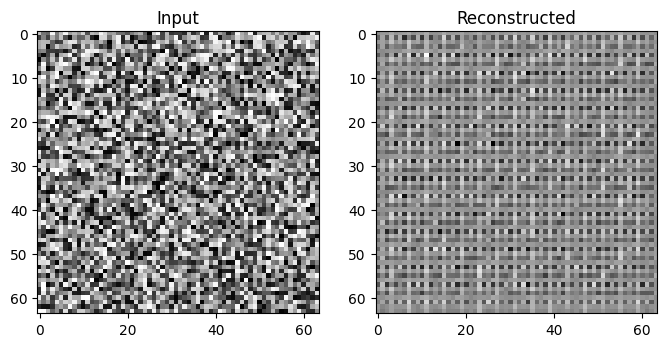

In [8]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    test[0, 0].cpu(),
    cmap="gray"
)
plt.title("Input")

plt.subplot(1, 2, 2)
plt.imshow(
    reconstructed[0, 0].cpu(),
    cmap="gray"
)
plt.title("Reconstructed")

plt.show()

In [9]:
print("Convolutional Autoencoder completed.")
print("SSIM reconstruction loss and anomaly detection completed.")

Convolutional Autoencoder completed.
SSIM reconstruction loss and anomaly detection completed.
